## Cargamos los datos

In [20]:
import pandas as pd
df = pd.read_parquet(r"C:\Users\gemma\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet")
df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_week_order                    

# Plan de análisis

## Objetivo del análisis 

Determinar qué características de los empleados están asociadas con un mayor desempeno laboral.

Consideraremos que nuestro indicador de desempeno laboral es la variable hit_target.

## Valoración de análisis que se pueden realizar

### Correlación entre hit target y variables numéricas

Analizar la correlación entre hit_target y características de los empleados.

¿Qué variables analizamos? Considerar desde un punto de vista teórico, en base a artículos, qué características personales de los trabajadores pueden influir en el desempeno laboral. 

### Relación entre hit target y variables categóricas

Aquí haremos visualizaciones (e.g. boxplots) y tests estadisticos para comparar hit rate a través de las categorías.

Para categóricas binarias → t-test / Mann-Whitney (en función de si la distribución es normal o no).

Para categóricas multinivel → ANOVA / Kruskal-Wallis.

### Modelo predictivo (regresión lineal múltiple)

Predecir el hit_target en base a las características de los empleados. De esta forma, introduciendo sus características, podremos predecir su productividad. Esto nos servirá para saber qué perfil de personas contratar en el futuro. 

Empezaremos con un modelo que incluya todas las variables. Mediante un proceso de selección stepwise determinaremos cuál es el modelo que, con el mínimo número de variables, es capaz de explicar en mayor medida la variabilidad de la variable de respuesta. En otras palabras, nos quedaremos con las variables más importante a la hora de predecir la productividad. Finalmente, determinaremos qué peso tiene cada variable. 

# Correlación entre hit target y variables numéricas

In [21]:
# Calculamos la media de hit target de cada trabajador y nos quedamos con un solo registro por trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)

df.head()
df.shape[0]

136

Correlaciones significativas con Hit_target_avg:
                            rho      pval
Work_load_Average_day -0.203923  0.017253


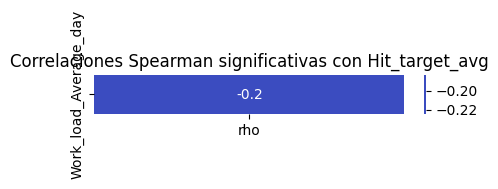

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Variables de interés
vars_interes = [
    "Transportation_expense","Distance_Residence_Work","Service_time","Age",
    "Work_load_Average_day","Son","Weight","Height","Body_mass_index"
]

target = "Hit_target_avg"
results = {}

# Calcular rho y p-valor para cada variable de interés
for col in vars_interes:
    rho, pval = spearmanr(df[target], df[col], nan_policy="omit")
    results[col] = {"rho": rho, "pval": pval}

# Convertimos a DataFrame
res_df = pd.DataFrame(results).T

# Filtramos las significativas (p < 0.05)
sig_res = res_df[res_df["pval"] < 0.05].sort_values("rho", ascending=False)

# Mostrar resultados
print("Correlaciones significativas con Hit_target_avg:")
print(sig_res)

# Graficar heatmap solo de las significativas
if not sig_res.empty:
    plt.figure(figsize=(5, len(sig_res) * 0.5))
    sns.heatmap(sig_res[["rho"]], annot=True, cmap="coolwarm", center=0)
    plt.title("Correlaciones Spearman significativas con Hit_target_avg")
    plt.show()
else:
    print("⚠️ Ninguna correlación significativa encontrada.")


## Relación entre hit target y variables categóricas